# CSE2530 Computational Intelligence
## Assignment 1: Artificial Neural Networks

<div style="background-color:#f1be3e">

_Fill in your group number **from Brightspace**, names, and student numbers._
    
|    Group   |           33          |
|------------|----------------------|
| Student A  |        Pavel Buta       |
| Student B  |        Diana Ghisoiu       |
| Student C  |        Tudor Petcu 5980445      |
| Student D  |        Adrian Olteanu       |

</div>

#### Imports

In [2]:
# You may only use numpy to implement your neural network
# You are not allowed to use scikit-learn, other than for Section 1.6.
# You are also not allowed to use Pytorch, Tensorflow, and similar machine learning frameworks.
# You can make use of any other libraries for miscellaneous functions, e.g. to create the visual aids.

# Put all of your imports in this code block
import numpy as np
import matplotlib.pyplot as plt

#### Loading the data

In [3]:
features = np.genfromtxt("../data/features.txt", delimiter=",")
targets = np.genfromtxt("../data/targets.txt", delimiter=",")
unknown = np.genfromtxt("../data/unknown.txt", delimiter=",")

## 1 Questions
### 1.2 Architecture
#### Question 1:

We implement a single perceptron with a step activation function and train it using the perceptron learning rule.
We train it on the truth tables for AND, OR, and XOR and plot the training error over epochs.

In [4]:
np.random.seed(0)

X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=float)

# Targets
y_and = np.array([0, 0, 0, 1], dtype=int)
y_or  = np.array([0, 1, 1, 1], dtype=int)
y_xor = np.array([0, 1, 1, 0], dtype=int)

#We now make a Perceptron class and implement methods such that we can call it nicely for the 3 logic gates
class Perceptron:
    def __init__(self, n_inputs: int, lr: float = 0.1):
        self.lr = lr
        self.w = np.random.uniform(-0.5, 0.5, size=n_inputs)
        self.b = np.random.uniform(-0.5, 0.5)

    #To predict the output for a single input, we calculate the net input and apply the step function as presented in the lecture
    def predict_one(self, x: np.ndarray) -> int:
        net = np.dot(self.w, x) + self.b
        return 1 if net >= 0 else 0  

    def predict(self, X: np.ndarray) -> np.ndarray:
        return np.array([self.predict_one(x) for x in X], dtype=int)

    def fit(self, X: np.ndarray, y: np.ndarray, epochs: int = 20):
        errors = []

        for _ in range(epochs):
            for x_i, y_i in zip(X, y):
                y_hat = self.predict_one(x_i)
                L = y_i - y_hat
                self.w += self.lr * L * x_i
                self.b += self.lr * L

            y_pred = self.predict(X)
            epoch_error = int(np.sum(np.abs(y - y_pred))) #here we made the error absolute so we can plot it nicely
            errors.append(epoch_error)
        
        #We could have also included a threshold to stop early, but the plots need to be uniform for all 3 logic gates, so we just run for a fixed (and small) number of epochs and plot the errors.
        return errors


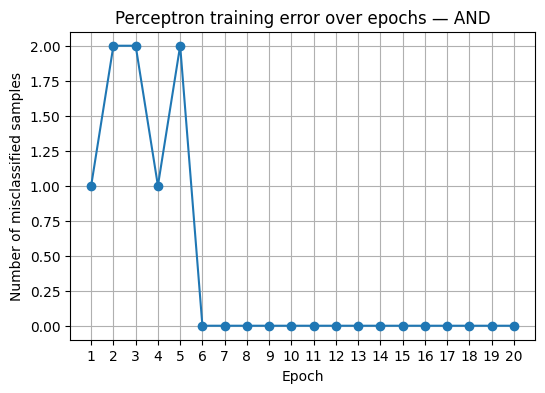

AND final error:       0
AND learned w: [0.2488135  0.11518937], b: -0.29723662392835615



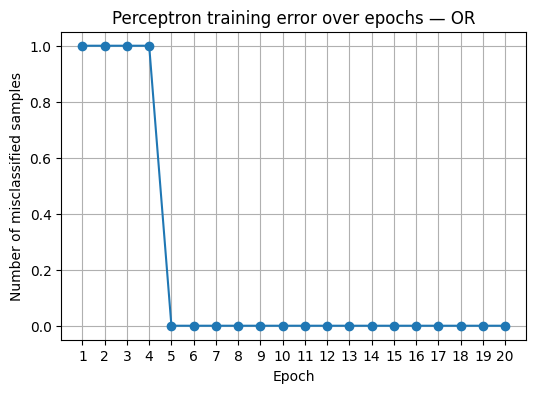

OR final error:       0
OR learned w: [0.14488318 0.1236548 ], b: -0.054105886933343894



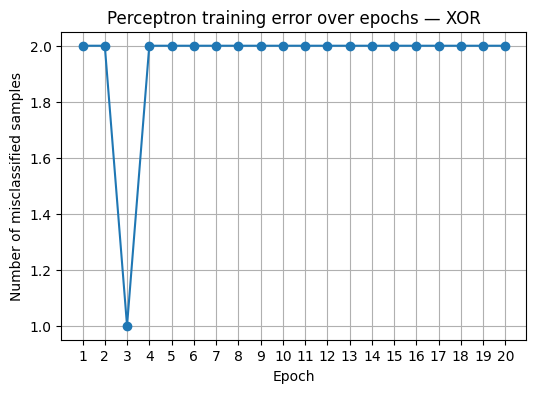

XOR final error:       2
XOR learned w: [-0.16241279 -0.008227  ], b: 0.06366276050102931



In [5]:
#Now we create the plots and train the perceptrons for the AND, OR, and XOR gates
def train_and_plot(gate_name: str, X: np.ndarray, y: np.ndarray, lr: float = 0.1, epochs: int = 20):
    p = Perceptron(n_inputs=X.shape[1], lr=lr)
    errors = p.fit(X, y, epochs=epochs)

    plt.figure(figsize=(6, 4))
    plt.plot(range(1, epochs + 1), errors, marker="o")
    plt.title(f"Perceptron training error over epochs — {gate_name}")
    plt.xlabel("Epoch")
    plt.ylabel("Number of misclassified samples")
    plt.xticks(range(1, epochs + 1))
    plt.grid(True)
    plt.show()

    final_pred = p.predict(X)
    print(f"{gate_name} final error:       {int(np.sum(np.abs(y - final_pred)))}")
    print(f"{gate_name} learned w: {p.w}, b: {p.b}\n")

    return errors

errors_and = train_and_plot("AND", X, y_and, lr=0.1, epochs=20)
errors_or  = train_and_plot("OR",  X, y_or,  lr=0.1, epochs=20)
errors_xor = train_and_plot("XOR", X, y_xor, lr=0.1, epochs=20)


### Discussion of the plots

**AND:** The error quickly drops to 0 and stays there. This means the perceptron found weights and a bias that separate the positive class (1,1) from the other three inputs with a single straight decision boundary.

**OR:** The error also drops to 0 and remains stable. OR is linearly separable as well: only (0,0) should be classified as 0, and a single linear boundary can separate (0,0) from the other points.

**XOR:** The error does *not* converge to 0; it typically oscillates or plateaus above 0. This happens because XOR is **not linearly separable**: the positive points (0,1) and (1,0) are on opposite corners, so no single line can separate the 1s from the 0s. A single perceptron can only represent linear decision boundaries, so it cannot perfectly learn XOR.

**Important:** The fact that we used random initialisation for the weights might help reaching 0 error rate faster in the case of AND and OR gates, but still does not affect the impossibility of learning a linear classifier for gate XOR.

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

</div>

#### Question 2

We need as many input neurons as there are features of our samples. In this case, we have 10 features/samples and, thus, 10 input neurons.

#### Question 3

Analogously, the output requires 7 neurons, equal to the amount of labels/classes.

#### Question 4

I don't expect that we'll need a large network for this classification task, since we don't have too much data, nor sample sizes that are too large (feature count). I would say 2-3 hidden layers and probably between 7-15 (possibly even less) neurons per layer.

#### Question 5

I will be using sigmoid activation functions, more specifically logistic functions on every layer except the final one. For the output layer I will apply a softmax to give a probability distribution of the classes/labels, to allow for multiclass classification.

#### Question 6

input layer (10 neurons) -> hidden_layer_1 (x inputs) -> logistic_activation_1 (x inputs) -> ... -> hidden_layer_n (y inputs) -> logistic_activation_n (y inputs) -> output_layer (7 neurons) -> softmax_activation (7 inputs)

### 1.3 Training

When coding a neural network from scratch, it helps to think of a layer as an individual component that can be easily combined with other layers. To help you create a modular implementation of a neural network, we provide you with a template for the implementation along with some explanations.

**Note that using the template below is not mandatory. You may choose to modify this template or implement your own version of the neural network altogether. If the latter, please remove our template from the notebook and ensure that it instead includes a complete, fully functional implementation of your own.**

**Linear (fully connected) layer**

A linear or fully connected layer maps the input data to an output by performing a linear transformation, where each input neuron is connected to every output neuron. The forward pass of a linear layer is computed as $y = wx + b$, where $w$ and $b$ are trainable parameters. The gradients of the loss with respect to $w$ and $b$ are defined using the chain rule:

$$\frac{\partial \mathcal{L}}{\partial w}=\frac{\partial \mathcal{L}}{\partial y} \cdot \frac{\partial y}{\partial w}, \quad \frac{\partial \mathcal{L}}{\partial b}=\frac{\partial \mathcal{L}}{\partial y} \cdot \frac{\partial y}{\partial b}, $$

where $\frac{\partial \mathcal{L}}{\partial y}$ is the upstream gradient i.e., the gradient flowing from deeper layers into the current layer, and the other two terms are the local gradients:

$$
\frac{\partial y}{\partial w}=x, \quad \frac{\partial y}{\partial b}=1.
$$

Since $x$ is needed to compute the gradients, we can store (cache) its value during the forward pass. Finally, we need to return a downstream gradient so that more shallow layers can use it as their upstream gradient. The downstream gradient of a layer is simply its upstream gradient multiplied by the local gradient of its ouput with respect to its input:

$$
\frac{\partial \mathcal{L}}{\partial x}=\frac{\partial \mathcal{L}}{\partial y} \cdot \frac{\partial y}{\partial x}
$$

**Note.** Be aware of how you multiply the arrays, it might be useful to print the shapes of each array and to think about the desired shape of the output.  

In [69]:
class Linear:
    def __init__(self, in_features, out_features, random_seed, init_strategy):
        """ Randomly initialize the weights and biases.

        Args:
            in_features: number of input features.
            out_features: number of output features.
        """
        rng = np.random.default_rng(random_seed)

        # each row corresponds to one input
        # and each column to one output
        self.bias = np.zeros(out_features)
        if init_strategy == 0:
            self.weight = rng.normal(0, np.sqrt(1 / in_features), (in_features, out_features)) # xavier initialization
        elif init_strategy == 1:
            self.weight = rng.random((in_features, out_features))
        else:
            raise Exception("[LINEAR] given argument does not represent a valid initialization strategy\n")
            

        # cache contains values for the input of the layer
        # (as given during the forward pass)
        self.cache = None
        # For storing the gradients w.r.t. the weight and the bias
        self.weight_grad = None
        self.bias_grad = None

    # this input already has the activation function applied
    # I am furthermore assuming that x is a row vector
    def forward(self, x):
        """ Perform the forward pass of a linear layer. 
        Store (cache) the input so it can be used in the backward pass.

        Args:
            x: input of a linear layer.

        Returns: 
            y: output of a linear layer. 
        """

        # store input for gradient calculation
        self.cache = x

        # expand dims to make sure self.bias broadcasts correctly
        y = x @ self.weight + np.expand_dims(self.bias, axis=0) # (@ is matrix multiplication)
        assert y.shape == (x.shape[0], len(self.bias)), "[LINEAR] shape of output in forward pass incorrect\n"
        return y  
    
    def backward(self, dupstream):
        """ Perform the backward pass of a linear layer.  

        Args:
            dupstream: upstream gradient. 

        Returns:
            dx: downstream gradient.
        """
    
        # here we should also calculate the grad for the weights and bias
        # which we store in weight_grad and bias_grad and apply during optimization

        assert type(self.cache) is np.ndarray, "[LINEAR] cache value not set\n"
        x = self.cache
        # get batch size
        b = x.shape[0]

        # each of the inputs gives an array for the weight gradient
        # should be column x row (but it probably doesn't matter)
        chosen_axis = 1 # because, as 1d array, x is of the shape 1 x f (f == number of features/inputs)
        # (could also have done expand_dims, but whatever)
        extra_args = [dupstream] # extra arguments to be passed to np.outer
        self.weight_grad = np.apply_along_axis(np.outer, chosen_axis, x, *extra_args) # a 3d array (or 2d if b == 1)
        #print(x.shape, b, self.weight_grad.shape, self.weight.shape)
        assert self.weight_grad.shape == (b, self.weight.shape[0], self.weight.shape[1]), "[LINEAR] shape of weight gradient in layer wrong\n"
        # we sum over each of the matrices then average by dividing by batch size
        self.weight_grad = np.mean(self.weight_grad, axis=0)
        #self.weight_grad = np.sum(self.weight_grad, axis=0) # sum instead
        assert self.weight_grad.shape == self.weight.shape, "[LINEAR] final result of gradient doesn't match weight matrix size\n"

        self.bias_grad = dupstream # I hope this either doesn't reference or will behave nicely

        # upstream is derivative wrt. z (so, without activation function)
        # dx will be an array of values for derivatives wrt. h (with activation function)
        # (which will be dealt with in the code for the activation function)
        assert self.weight.shape[1] == len(dupstream), "[LINEAR] upstream derivative size is different from what is expected\n"
        dx = self.weight @ dupstream # size is equal to input size (x)
        # x should be a row (i.e. 1 x f, where f is the number of features)
        feature_count = x.shape[1]
        assert len(dx) == feature_count, "[LINEAR] gradient output should have the same shape as x\n"
        return dx

**Activation functions**

You also need to implement an activation function suitable for the task at hand.

Think about how to perform the backward pass i.e., what is the local gradient and what the downstream gradient should be. Do not forget to take the upstream gradient into account.

In [57]:
class Activation:
    def __init__(self):
        self.cache = None
    
    # computes the value of the logistic function for parameter(s)
    def logistic(self, x):
        # equivalent expressions picked to avoid overflows given the value of x
        # (since underflows are better behaved than overflows)
        res = np.where(x < 0, np.exp(x) / (1 + np.exp(x)), 1 / (1 + np.exp(-x)))
        return res

    def forward(self, x):
        """ Perform a forward pass of your activation function.
        Store (cache) the output so it can be used in the backward pass.

        Args:
            x: input to the activation function. 

        Returns:
            y: output of the activation function.
        """

        self.cache = x
        # x is z vector, to be transformed into y, ie. h vector
        # I will just use the logistic (sigmoid) function
        h = self.logistic(x)
        assert h.shape == x.shape, "[ACTIVATION] logistic application changes array shape\n" # shape should be maintained
        return h
    
    def backward(self, dupstream): 
        """ Perform a backward pass of the activation function. 
        Make sure you do not modify the original dupstream.

        Args:
            dupstream: upstream gradient. 

        Returns:
            dx: downstream gradient.
        """
        
        x = self.cache
        feature_count = x.shape[1]
        assert len(dupstream) == feature_count, "[ACTIVATION] dupstream or x not expected shape\n" # amount of features should be the same
        h = self.logistic(x)
        dx = np.multiply(np.expand_dims(dupstream, axis=0), np.multiply(h, 1 - h)) # this gives a matrix for all samples which needs to be averaged
        dx = np.mean(dx, axis=0) # average over the whole batch
        #dx = np.sum(dx, axis=0) # sum instead (this seems to behave better while not overflowing)
        assert dx.shape == dupstream.shape, "[ACTIVATION] calculated gradient doesn't have the same shape as input gradient\n" # gradient maintains shape
        return dx

**Network** 

Now that you have implemented a `Linear` layer and an activation function, you can combine them in different ways and have the `Network` class perform forward and backward passes through all layer of the network in the specified order.

Additionally, you should make the `Network` class update all the trainable parameters of the network in `optimizer_step`.

In [ ]:
def softmax(y):
    if y.ndim == 1:
        exp_sum = np.sum(np.exp(y))
        return np.exp(y) / exp_sum
    
    exp_sum = np.sum(np.exp(y), axis=1)
    exp_sum = np.expand_dims(exp_sum, axis=-1) # for broadcasting to work, have to "add" the extra dimension to the 1d array
    return np.exp(y) / exp_sum

In [41]:
# this avoids overflows and is equal to softmax(y)
def stable_softmax(y):
    y = y - np.max(y, axis=1, keepdims=True)
    assert np.count_nonzero(np.where(y > 1, 1, 0)) == 0, "[STABLE SOFTMAX] stable softmax expects all values <= 0\n"
    if y.ndim == 1:
        exp_sum = np.sum(np.exp(y))
        return np.exp(y) / exp_sum
    
    exp_sum = np.sum(np.exp(y), axis=1)
    exp_sum = np.expand_dims(exp_sum, axis=-1) # for broadcasting to work, have to "add" the extra dimension to the 1d array
    return np.exp(y) / exp_sum

In [40]:
class Network:
    def __init__(self, layers):
        self.layers = layers # this contains Linear as well as Activation objects

    def forward(self, x):
        """ Perform a forward pass over the entire network.

        Args:
            x: input data. 

        Returns:
            y: predictions.
        """
        
        y = x
        for l in self.layers:
            #print(str(type(l)) + ' ' + str(y))
            y = l.forward(y)

        # apply softmax at the end for probability distribution over classes
        # (multiclass classification)
        #print('Final: ' + str(y))
        #print(y.shape, np.max(y, axis=1, keepdims=True).shape)
        soft = stable_softmax(y)
        #print('Softmax' + str(soft) + '\n')
        return soft
    
    def backward(self, dupstream):
        """ Perform a backward pass over the entire network.

        Args:
            dupstream: upstream gradient. 

        Returns:
            dx: downstream gradient.
        """
        
        # (I assume that dupstream is direct derivative of loss from outputs of final layer, without logistic derivative)
        # activation will be doing differentation to get it to the right value for the layer backward step
        dx = dupstream
        #print('dupstream ' + str(dupstream))
        # go in reverse order
        for l in reversed(self.layers):
            dx = l.backward(dx)
            #print(str(type(l)) + ' ' + str(dx))

        #print('\n\n')
        return dx
    
    def optimizer_step(self, lr):
        """ Update the weight and bias parameters of each layer.

        Args:
            lr: learning rate.
        """
        
        for l in self.layers:
            # since activation doesn't have anything to optimize
            if(type(l) is Linear):
                l.weight = l.weight - lr * l.weight_grad
                l.bias = l.bias - lr * l.bias_grad

**Loss function**

You also need to implement a loss function that will measure how well your neural network performs at the task.

In [10]:
label_count = 7

In [11]:
def cross_entropy_loss(y_pred, y_true):
    """ Computes the value of the loss function and its gradient.  

    Args:
        y_true: 1-hot true vector(s).
        y_pred: predictions made (softmax probability distribution).

    Returns:
        loss: value of the loss. 
        grad: gradient of loss with respect to the predictions. 
    """

    assert y_pred.shape == y_true.shape, "[CROSS ENTROPY LOSS] predictions do not match shape of ground truth vector(s)\n"
    b = 1 if y_pred.ndim == 1 else y_pred.shape[0]
    assert b > 0, "[CROSS ENTROPY LOSS] batch size somehow 0 or less\n"
    loss = -np.sum(np.multiply(np.log(y_pred), y_true)) / b

    if b == 1:
        gradient = y_pred - y_true
    else:
        gradient = np.sum(y_pred - y_true, axis=0)
        
    classes = y_pred.shape[0] if b == 1 else y_pred.shape[1]
    assert gradient.shape[0] == classes, "[CROSS ENTROPY LOSS] gradient size is not a vector with size equal to amount of classes\n"
    return loss, gradient
    

**Training loop**

Finally, define a training loop in which for each optimizer step you:

1. Obtain the predictions by performing a forward pass of the network;

2. Compute the loss and its gradient by comparing the predictions with the ground truth according to the selected criterion;

3. Perform a backward pass of the network;

4. Update all parameters of the network i.e, take an optimizer step.

In [35]:
def compute_accuracy(net, inputs, labels):
    pred = net.forward(inputs)
    assert inputs.ndim > 1, "[ACCURACY COMPUTATION] dataset contains less than 2 datapoints\n"
    
    predicted_labels = np.argmax(pred, axis=1) + 1
    return np.count_nonzero(np.where(predicted_labels == labels, 1, 0)) / inputs.shape[0]

In [60]:
def train(net, inputs, labels, criterion, lr, batch_size, epoch_count, label_count):
    """Trains the neural network.

    Args:
        net: network or model. 
        inputs: input data.
        labels: labels. 
        criterion: loss function.
        lr: learning rate.

    Returns:
        losses: a list containing the loss at every optimizer step. 
        accuracies: a list containing the accuracy at every optimizer step. 
    """
    
    losses = [[] for i in range(epoch_count)]
    accuracies = []
    n = inputs.shape[0]
    for e in range(epoch_count):
        #print("\n\n------------------------ NEW EPOCH START ------------------------\n\n")
        i = 0
        while(i < n):
            add = min(n - i, batch_size)
            x = inputs[i:i + add]
            pred = net.forward(x)
            # make label(s) into 1-hot vector(s)
            target = np.zeros((add, label_count))
            for j in range(add):
                target[j][int(labels[i + j] - 1)] = 1

            loss, grad = criterion(pred, target) # here should pass cross_entropy_loss in (generic criterion doesn't make sense imo but whatever)
            if grad.shape == (1, label_count):
                grad = grad[0] # goes from 1xf to just a normal 1d array

            net.backward(grad)
            net.optimizer_step(lr)

            losses[e].append(loss)
            i += add

        accuracies.append(compute_accuracy(net, inputs, labels))

    return losses, accuracies

In [77]:
def build_network(neurons_per_layer, feature_count, label_count, random_seed, initialization_strategy):
    """Creates a neural network based on given specifications.

    Args:
        neurons_per_layer: array with neuron count for each hidden layer.
        feature_count: size of input vectors (sample size). 
        label_count: size of output vector/prediction vector (number of classes).
        random_seed: random seed for the layer initialization.
        initialization_strategy: 0 for Xavier, 1 for random. Other values raise an exception
    Returns:
        net: network containing the correct layers (Linear and Activation functions). 
    """
    layer_count = len(neurons_per_layer)
    layers = []
    layer_in = feature_count
    layer_out = 0
    for i in range(layer_count):
        layer_out = neurons_per_layer[i]
        layers.append(Linear(layer_in, layer_out, random_seed, initialization_strategy))
        layers.append(Activation())
        layer_in = layer_out

    layers.append(Linear(layer_in, label_count, random_seed, initialization_strategy))
    net = Network(layers)
    return net

Greatest Achieved Accuracy: 0.9397759103641457


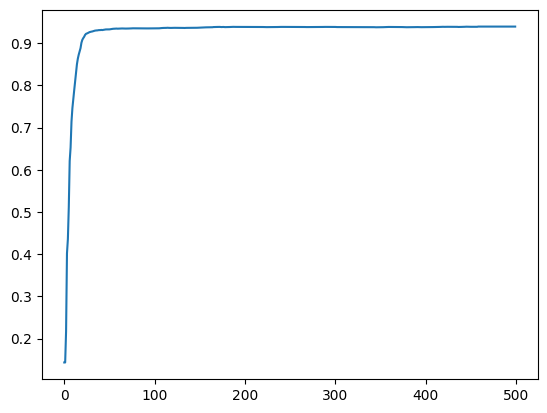

In [78]:
neurons_per_layer = [12, 8, 5] # by layers I mean hidden layers (+2 total layers including input vector and output vector/predictions)
feature_count = 10 # (i.e. input vector size)
net = build_network(neurons_per_layer, feature_count, label_count, 33, 0)
losses, accuracies = train(net, features, targets, cross_entropy_loss, 0.01, 1, 500, label_count)
#print(losses)
#print(accuracies)
print("Greatest Achieved Accuracy:", np.max(accuracies))
plt.plot(accuracies)

#### Question 7

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

</div>

#### Question 8

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

</div>

#### Question 9

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

</div>

#### Question 10

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

</div>

### 1.4 Optimization

#### Question 11

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

</div>

#### Question 12

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

</div>

### 1.5 Evaluation

#### Question 13

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

</div>

#### Question 14

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

</div>

#### Question 15

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

</div>

### 1.6 Scikit-learn

#### Question 16

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

</div>

#### Question 17

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

</div>

### 1.7 Reflection

#### Question 18

<div style="background-color:#f1be3e">

_Write your answer here._

</div>

#### Question 19

<div style="background-color:#f1be3e">

_Write your answer here._

</div>

### 1.8 Pen and paper

#### Question 20

<div style="background-color:#f1be3e">

_Write your answer here. You can also choose to simply include a photo of your solution._

</div>

#### Question 21

<div style="background-color:#f1be3e">

_Write your answer here. You can also choose to simply include a photo of your solution._

</div>

### 1.9 Division of work

#### Question 22

<div style="background-color:#f1be3e">


|          Component          |  Name A   |  Name B   |  Name C   |  Name D   |
|-----------------------------|-----------|-----------|-----------|-----------|
| Code (design)               |     A     |     B     |     C     |     D     |
| Code (implementation)       |     A     |     B     |     C     |     D     |
| Code (validation)           |     A     |     B     |     C     |     D     |
| Experiments (execution)     |     A     |     B     |     C     |     D     |
| Experiments (analysis)      |     A     |     B     |     C     |     D     |
| Experiments (visualization) |     A     |     B     |     C     |     D     |
| Report (original draft)     |     A     |     B     |     C     |     D     |
| Report (reviewing, editing) |     A     |     B     |     C     |     D     |

</div>

### References

<div style="background-color:#f1be3e">

**If you made use of any non-course resources, cite them below.**

</div>